# Recipe Site Traffic: Data Science Practical Exam

**Company:** Tasty Bytes  
**Project:** Predicting which recipes will generate high traffic on the homepage.  
**Objective:** To build a classification model that correctly identifies high-traffic recipes at least **80% of the time**, while minimising the chance of featuring unpopular recipes.

## 1. Data Validation

The dataset was provided by the product manager and contains 947 rows and 8 columns. Before any analysis or modelling, each column is validated against the data dictionary to ensure quality and correctness. Cleaning decisions made here are documented in full.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
GREY = '#808080'

In [2]:
# Load data
df = pd.read_csv('E:\\Data Science Course\\Projects\\Data Science Projects\\Practical Exam\\recipe_site_traffic_2212.csv')
print(f'Shape: {df.shape}')
df.info()

Shape: (947, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [3]:
df.head(10)

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN
5,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High
6,7,183.94,47.95,9.75,46.71,Chicken Breast,4,NaN
7,8,299.14,3.17,0.40,32.40,Lunch/Snacks,4,NaN
8,9,538.52,3.78,3.37,3.79,Pork,6,High
9,10,248.28,48.54,3.99,113.85,Chicken,2,NaN


### Column-by-Column Validation

In [4]:
# recipe
# Numeric unique identifier
print('recipe - unique values:', df['recipe'].nunique())
print('recipe - duplicates   :', df['recipe'].duplicated().sum())
print('recipe - nulls        :', df['recipe'].isnull().sum())

recipe - unique values: 947
recipe - duplicates   : 0
recipe - nulls        : 0


**`recipe`** — 947 unique integer identifiers, zero duplicates, zero nulls. Matches the data dictionary. This column is an ID and will **not** be used as a feature.

In [5]:
# Numeric nutrition columns: calories, carbohydrate, sugar, protein
nutrition_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
print('Missing values per nutrition column:')
print(df[nutrition_cols].isnull().sum())
print()
print('Descriptive statistics:')
df[nutrition_cols].describe()

Missing values per nutrition column:
calories        52
carbohydrate    52
sugar           52
protein         52
dtype: int64

Descriptive statistics:


,calories,carbohydrate,sugar,protein
count,895.000000,895.000000,895.000000,895.000000
mean,435.939196,35.069676,9.046547,24.149296
std,453.020997,43.949032,14.679176,36.369739
min,0.140000,0.030000,0.010000,0.000000
25%,110.430000,8.375000,1.690000,3.195000
50%,288.550000,21.480000,4.550000,10.800000
75%,597.650000,44.965000,9.800000,30.200000
max,3633.160000,530.420000,148.750000,363.360000


In [6]:
# Check whether missing values occur on the same rows across all four columns
missing_mask = df['calories'].isnull()
print('All four nutrition cols missing on the same 52 rows?',
      df.loc[missing_mask, nutrition_cols].isnull().all(axis=None))
print('Total rows with any nutrition missing:', missing_mask.sum())

All four nutrition cols missing on the same 52 rows? True
Total rows with any nutrition missing: 52


**calories, carbohydrate, sugar, protein** — All four nutrition columns share the same 52 missing rows (5.5% of the dataset). All values that are present are positive numerics, consistent with the data dictionary.  

**Decision:** We will replace the 52 missing values with the **column median** for each variable. Median imputation is preferred over the mean here because the distributions are right-skewed. Dropping these rows entirely would remove 5.5% of observations, which is unnecessary given that median imputation introduces minimal bias for a small fraction of missing data.

In [7]:
# Impute missing nutrition values with median
for col in nutrition_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'{col}: imputed {missing_mask.sum()} missing values with median = {median_val:.2f}')

print('\nRemaining nulls in nutrition columns:')
print(df[nutrition_cols].isnull().sum())

calories: imputed 52 missing values with median = 288.55
carbohydrate: imputed 52 missing values with median = 21.48
sugar: imputed 52 missing values with median = 4.55
protein: imputed 52 missing values with median = 10.80

Remaining nulls in nutrition columns:
calories        0
carbohydrate    0
sugar           0
protein         0
dtype: int64


In [8]:
# category
print('category - unique values:', df['category'].nunique())
print(df['category'].value_counts())

category - unique values: 11
category
Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: count, dtype: int64


**category** — The data dictionary states **10** possible categories, but the data contains **11**: both **'Chicken'** and **'Chicken Breast'** are present. These appear to represent the same food group under two different labels.  

**Decision:** We will merge **'Chicken Breast'** into **'Chicken'** to align the data with the documented 10-category schema and reduce noise in the categorical feature.

In [9]:
# Merge 'Chicken Breast' into 'Chicken'
df['category'] = df['category'].replace('Chicken Breast', 'Chicken')
print('category - unique values after merge:', df['category'].nunique())
print(df['category'].value_counts())

category - unique values after merge: 10
category
Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: count, dtype: int64


In [10]:
# servings
# Expected: numeric
print('servings - unique raw values:', df['servings'].unique())
print('servings - dtype:', df['servings'].dtype)

servings - unique raw values: ['6' '4' '1' '2' '4 as a snack' '6 as a snack']
servings - dtype: object


**servings** — The column is stored as a string and contains two non-numeric entries: **'4 as a snack'** and **'6 as a snack'**. The numeric part of these strings (4 and 6) carries the meaningful information.  

**Decision:** Extract the leading integer from all values, converting the column to numeric type. No information is lost as the snack context is already captured by the **category** column.

In [11]:
# Extract numeric part of servings
df['servings'] = df['servings'].str.extract(r'(\d+)').astype(int)
print('servings - unique values after cleaning:', sorted(df['servings'].unique()))
print('servings - dtype:', df['servings'].dtype)

servings - unique values after cleaning: [1, 2, 4, 6]
servings - dtype: int32


In [12]:
# high_traffic
# Expected: 'High' when traffic was high; blank/NaN otherwise
print('high_traffic - raw value counts (including NaN):')
print(df['high_traffic'].value_counts(dropna=False))

high_traffic - raw value counts (including NaN):
high_traffic
High    574
NaN     373
Name: count, dtype: int64


**high_traffic** — The column contains **'High'** for 574 recipes and **NaN** for the remaining 373. The data dictionary states: *"if the traffic to the site was high when this recipe was shown, this is marked with 'High'"* — confirming that NaN means traffic was **not** high.  

**Decision:** Encode this column as a binary target variable: **1** for **'High'**, **0** for NaN (not high). This prepares the column for binary classification modelling.

In [13]:
# Encode target: 1 = High traffic, 0 = Not high traffic
df['high_traffic'] = df['high_traffic'].apply(lambda x: 1 if x == 'High' else 0)
print('high_traffic - encoded value counts:')
print(df['high_traffic'].value_counts())
print(f'\nClass balance - High: {df["high_traffic"].mean()*100:.1f}%  |  Not High: {(1-df["high_traffic"].mean())*100:.1f}%')

high_traffic - encoded value counts:
high_traffic
1    574
0    373
Name: count, dtype: int64

Class balance - High: 60.6%  |  Not High: 39.4%


In [14]:
# Final state of the cleaned dataset
print('Final shape:', df.shape)
print('\nRemaining nulls:')
print(df.isnull().sum())
df.head()

Final shape: (947, 8)

Remaining nulls:
recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,288.55,21.48,4.55,10.80,Pork,6,1
1,2,35.48,38.56,0.66,0.92,Potato,4,1
2,3,914.28,42.68,3.09,2.88,Breakfast,1,0
3,4,97.03,30.56,38.63,0.02,Beverages,4,1
4,5,27.05,1.85,0.80,0.53,Beverages,4,0


**Validation Summary**

| Column | Issue Found | Action Taken |
|---|---|---|
| **recipe** | None | No change — dropped from features (ID only) |
| **calories** | 52 missing values | Median imputation |
| **carbohydrate** | 52 missing values (same rows) | Median imputation |
| **sugar** | 52 missing values (same rows) | Median imputation |
| **protein** | 52 missing values (same rows) | Median imputation |
| **category** | 11 unique values (expected 10); **'Chicken'** and **'Chicken Breast'** both present | Merged **'Chicken Breast'** → **'Chicken'** |
| **servings** | Non-numeric entries (**'4 as a snack'**, **'6 as a snack'**) | Extracted leading integer; cast to int |
| **high_traffic** | 373 NaN values meaning "not high" | Encoded: **High** → 1, NaN → 0 |

---

## 2. Exploratory Data Analysis (EDA)

We explore the target variable, numeric features, and categorical features individually, then examine their relationships with the target (**high_traffic**). This section answers the product manager's core question: *which recipe characteristics are associated with high site traffic?*

### 2.1 Target Variable — **high_traffic**

The target variable is binary. We first inspect its overall distribution to understand class balance before modelling.

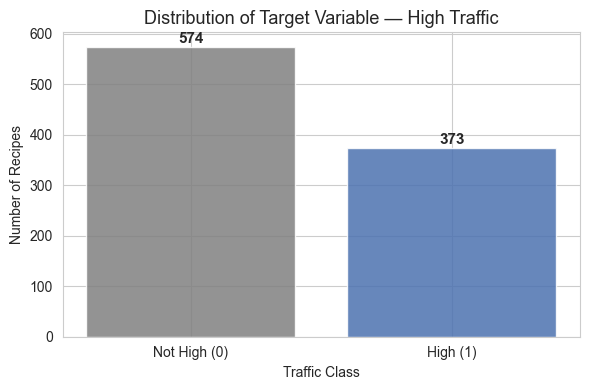

In [15]:
# Single-variable chart 1: Bar chart of target class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['high_traffic'].value_counts()
ax.bar(['Not High (0)', 'High (1)'], counts.values, color=[GREY, '#4C72B0'], alpha=0.85)
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Target Variable — High Traffic', fontsize=13)
ax.set_ylabel('Number of Recipes')
ax.set_xlabel('Traffic Class')
plt.tight_layout()
plt.show()

**Finding:** **574 recipes (60.6%)** generated high traffic and **373 (39.4%)** did not. The dataset is moderately imbalanced but not severely so - high traffic is the majority class. This means that a naive model predicting "High" every time would achieve ~61% accuracy, establishing a natural baseline to beat.

### 2.2 Numeric Features - Distributions

We examine the individual distributions of the 4 numeric nutrition features.

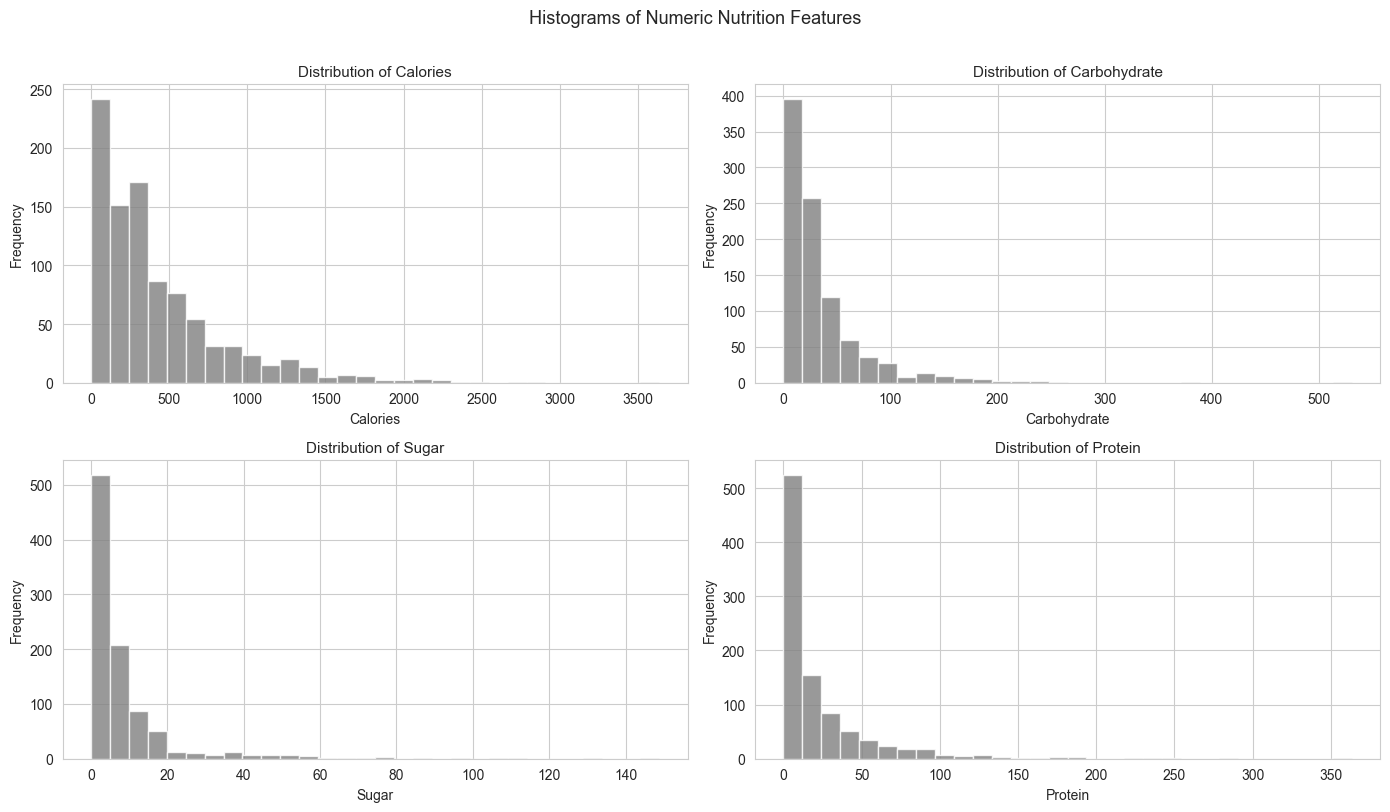

In [16]:
# Single-variable chart 2: Histograms for all 4 numeric nutrition features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(nutrition_cols):
    axes[i].hist(df[col], bins=30, color=GREY, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=11)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numeric Nutrition Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Finding:** All four nutrition variables are **right-skewed** with long upper tails — a small number of very high-calorie or high-carbohydrate recipes pull the mean above the median. Calories has the most extreme outliers (some recipes exceeding 3,000 kcal). This confirms the earlier decision to use median rather than mean imputation.

### 2.3 Categorical Feature — **category**

We inspect the distribution of recipe categories.

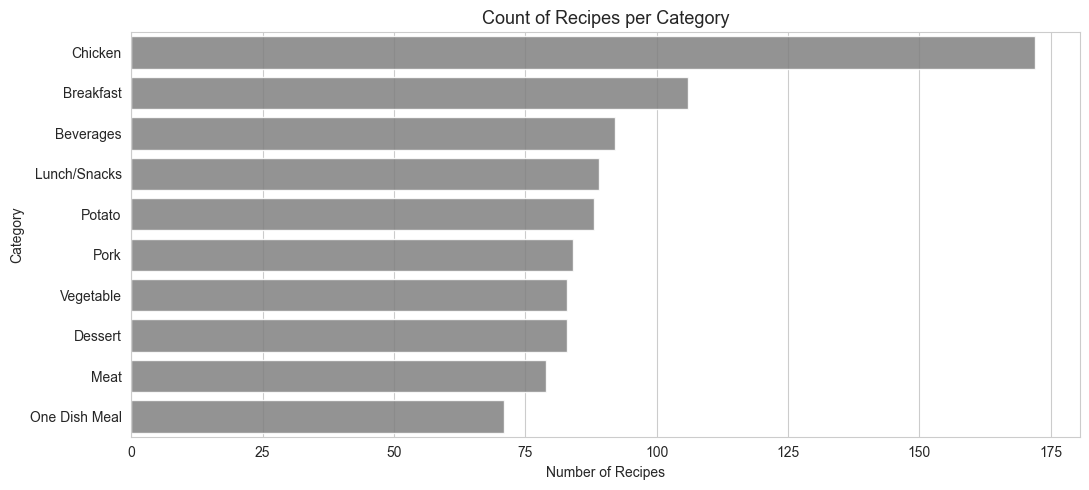

In [17]:
# Single-variable chart 3: Countplot of recipe categories
fig, ax = plt.subplots(figsize=(11, 5))
order = df['category'].value_counts().index
sns.countplot(data=df, y='category', order=order, color=GREY, alpha=0.85, ax=ax)
ax.set_title('Count of Recipes per Category', fontsize=13)
ax.set_xlabel('Number of Recipes')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

**Finding:** Breakfast (106) and Chicken (172, after merging) are the most represented categories, while One Dish Meal (71) is the least common. The distribution across categories is relatively even, so no single category dominates the dataset in a way that would introduce major bias.

### 2.4 Multi-variable Analysis — Features vs. High Traffic

We now investigate how each feature relates to the target variable.

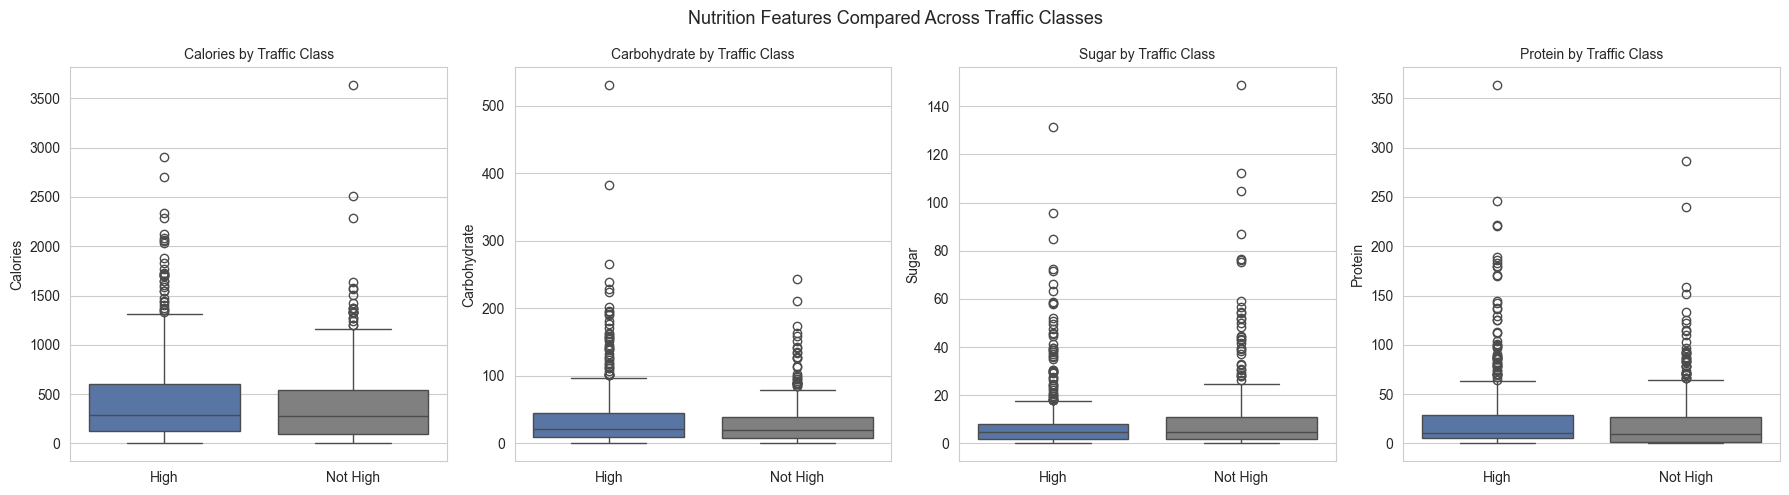

In [18]:
# Multi-variable chart 1: Boxplots of nutrition features split by traffic class
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
labels = {0: 'Not High', 1: 'High'}
df['traffic_label'] = df['high_traffic'].map(labels)

for i, col in enumerate(nutrition_cols):
    sns.boxplot(data=df, x='traffic_label', y=col, palette={'High': '#4C72B0', 'Not High': GREY},
                order=['High', 'Not High'], ax=axes[i])
    axes[i].set_title(f'{col.capitalize()} by Traffic Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col.capitalize())

plt.suptitle('Nutrition Features Compared Across Traffic Classes', fontsize=13)
plt.tight_layout()
plt.show()

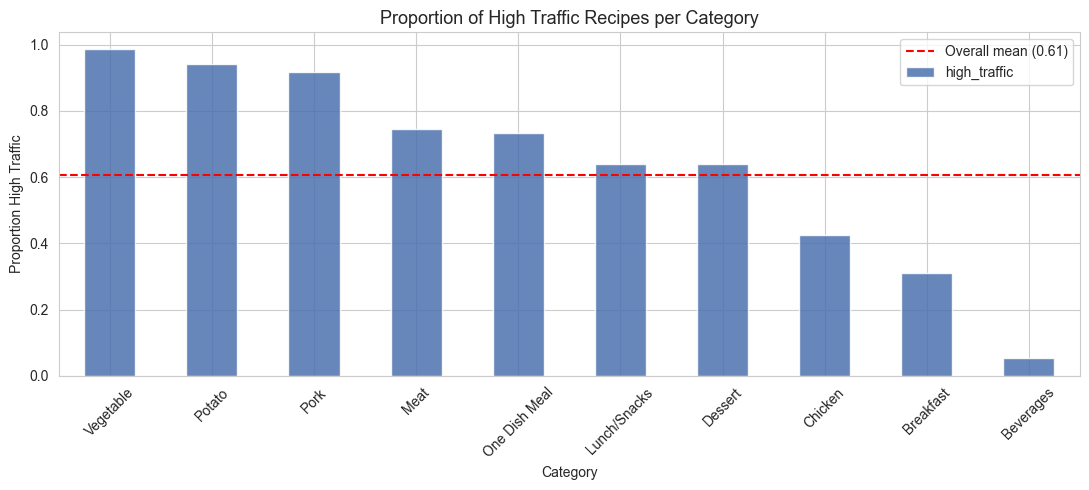

In [19]:
# Multi-variable chart 2: Stacked bar chart — High traffic proportion per category
cat_traffic = df.groupby('category')['high_traffic'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
cat_traffic.plot(kind='bar', color='#4C72B0', alpha=0.85, ax=ax)
ax.axhline(y=df['high_traffic'].mean(), color='red', linestyle='--', label=f'Overall mean ({df["high_traffic"].mean():.2f})')
ax.set_title('Proportion of High Traffic Recipes per Category', fontsize=13)
ax.set_ylabel('Proportion High Traffic')
ax.set_xlabel('Category')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

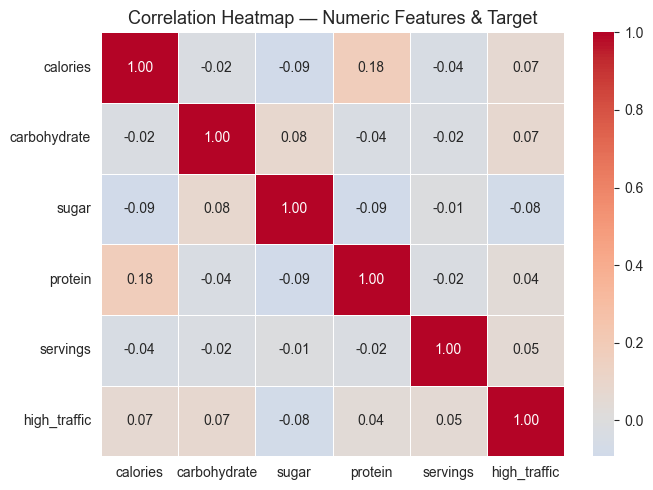

In [20]:
# Multi-variable chart 3: Correlation heatmap of numeric features
fig, ax = plt.subplots(figsize=(7, 5))
corr_cols = nutrition_cols + ['servings', 'high_traffic']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features & Target', fontsize=13)
plt.tight_layout()
plt.show()

**Findings from multi-variable analysis:**

- **Nutrition vs traffic:** The boxplots show that high-traffic recipes tend to have slightly lower median calories and carbohydrate compared to non-high-traffic recipes, but the overlap between classes is large. No single numeric feature strongly separates the two classes on its own.
- **Category vs traffic:** Category shows a clear pattern. Recipes in categories such as **Potato**, **Pork**, and **Vegetable** have notably higher proportions of high traffic than the overall average, while **Beverages** and **Breakfast** tend to fall below the overall mean. Category appears to be an important predictor.
- **Correlation heatmap:** Calories, carbohydrate, sugar, and protein are moderately positively correlated with each other (reflecting that larger/richer recipes tend to have more of everything). None of the numeric features shows a strong correlation with `high_traffic` individually, reinforcing that category is likely to be the most discriminating feature.

---

## 3. Model Development

### 3.1 Problem Type

This is a **binary classification** problem. The target variable **high_traffic** has two classes: **1** (High) and **0** (Not High). The goal is to maximise the **precision** for the positive class (High), meaning: when the model predicts a recipe will be popular, it should be correct as often as possible — ideally at least 80% of the time. Precision is the appropriate primary metric here because the product manager's core concern is *avoiding* featuring unpopular recipes, making false positives (predicting High when it is Not High) the more costly error.

In [21]:
### 3.2 Prepare Data for Modelling

# Features and target
feature_cols = ['calories', 'carbohydrate', 'sugar', 'protein', 'category', 'servings']
X = df[feature_cols].copy()
y = df['high_traffic']

# Encode the categorical column
le = LabelEncoder()
X['category'] = le.fit_transform(X['category'])

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Class distribution:\n', y.value_counts())

Feature matrix shape: (947, 6)
Target shape: (947,)
Class distribution:
 high_traffic
1    574
0    373
Name: count, dtype: int64


In [22]:
# Train/test split - 80% train, 20% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Training set size :', X_train.shape[0])
print('Test set size     :', X_test.shape[0])

Training set size : 757
Test set size     : 190


### 3.3 Baseline Model - Logistic Regression

Logistic Regression is chosen as the baseline because it is simple, interpretable, and well-suited to binary classification. It provides a sensible benchmark against which a more complex model can be compared.

In [23]:
# Fit Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

print('=== Logistic Regression ===')
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision (High): {prec_lr:.4f}')
print(f'Recall   (High): {rec_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Not High', 'High']))

=== Logistic Regression ===
Accuracy : 0.7684
Precision (High): 0.8660
Recall   (High): 0.7304

              precision    recall  f1-score   support

    Not High       0.67      0.83      0.74        75
        High       0.87      0.73      0.79       115

    accuracy                           0.77       190
   macro avg       0.77      0.78      0.77       190
weighted avg       0.79      0.77      0.77       190



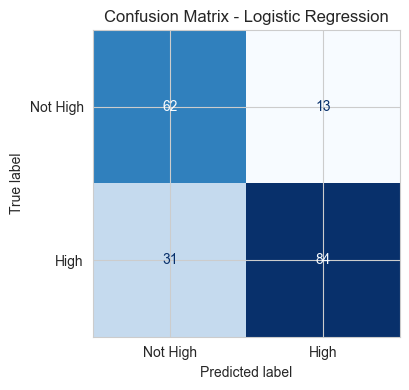

In [24]:
# Confusion matrix - Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Not High', 'High'],
    colorbar=False, cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

### 3.4 Comparison Model — Random Forest Classifier

Random Forest is selected as the comparison model because it can capture non-linear relationships and interactions between features that Logistic Regression cannot. To give the Random Forest the best chance, we use **GridSearchCV with 5-fold cross-validation** to search for the optimal hyperparameters before evaluating on the test set — mirroring the principled tuning approach used in the sample solution.

In [25]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5]
}

# Optimise for precision - the primary business metric
rf_cv = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_cv, param_grid,
    scoring='precision', cv=5, n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print('Best hyperparameters found:')
print(grid_search.best_params_)
print(f'Best cross-validated precision: {grid_search.best_score_:.4f}')

Best hyperparameters found:
{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated precision: 0.7824


In [26]:
# Evaluate the best Random Forest on the test set
rf = grid_search.best_estimator_
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)

print('=== Random Forest Classifier (Tuned) ===')
print(f'Accuracy         : {acc_rf:.4f}')
print(f'Precision (High) : {prec_rf:.4f}')
print(f'Recall   (High)  : {rec_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Not High', 'High']))

=== Random Forest Classifier (Tuned) ===
Accuracy         : 0.7895
Precision (High) : 0.8505
Recall   (High)  : 0.7913

              precision    recall  f1-score   support

    Not High       0.71      0.79      0.75        75
        High       0.85      0.79      0.82       115

    accuracy                           0.79       190
   macro avg       0.78      0.79      0.78       190
weighted avg       0.80      0.79      0.79       190



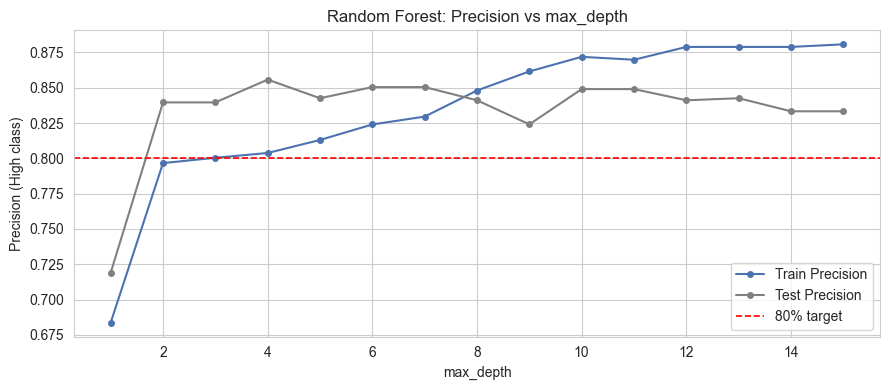

In [27]:
# Justification of the chosen hyperparameter
train_prec_list = []
test_prec_list  = []
depths = list(range(1, 16))

for d in depths:
    rf_d = RandomForestClassifier(
        n_estimators=200, max_depth=d,
        min_samples_leaf=5, random_state=42
    )
    rf_d.fit(X_train, y_train)
    train_prec_list.append(precision_score(y_train, rf_d.predict(X_train)))
    test_prec_list.append(precision_score(y_test,  rf_d.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_prec_list, label='Train Precision', color='#4C72B0', marker='o', markersize=4)
ax.plot(depths, test_prec_list,  label='Test Precision',  color=GREY,      marker='o', markersize=4)
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.2, label='80% target')
ax.set_title('Random Forest: Precision vs max_depth', fontsize=12)
ax.set_xlabel('max_depth')
ax.set_ylabel('Precision (High class)')
ax.legend()
plt.tight_layout()
plt.show()

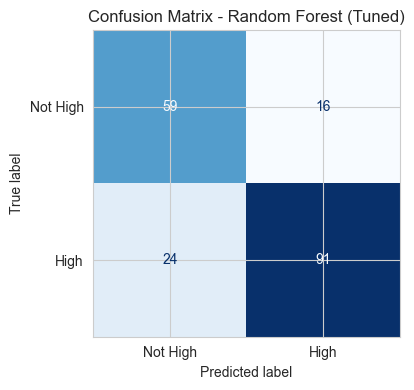

In [28]:
# Confusion matrix - Tuned Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Not High', 'High'],
    colorbar=False, cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix - Random Forest (Tuned)')
plt.tight_layout()
plt.show()

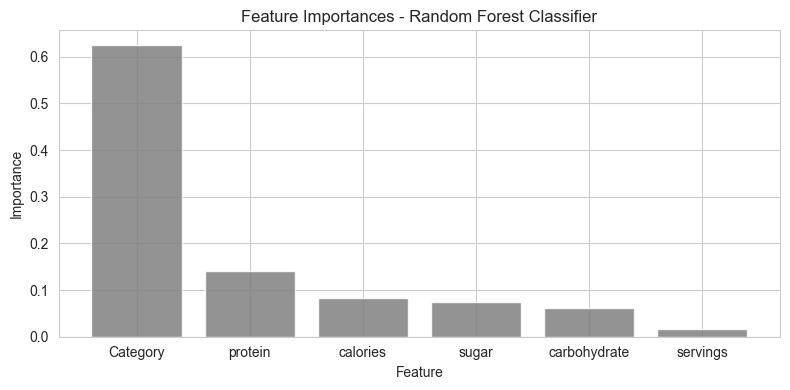

In [29]:
# Feature importances - Random Forest
importances = rf.feature_importances_
feat_labels = feature_cols.copy()
feat_labels[feat_labels.index('category')] = 'Category'

sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    [feat_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=GREY, alpha=0.85
)
ax.set_title('Feature Importances - Random Forest Classifier', fontsize=12)
ax.set_ylabel('Importance')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

---

## 4. Model Evaluation

We compare both models across three metrics: **Accuracy**, **Precision (High class)**, and **Recall (High class)**. Given the business objective, **Precision** is the most critical metric.

In [30]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest (Comparison)'],
    'Accuracy': [round(acc_lr, 4), round(acc_rf, 4)],
    'Precision (High)': [round(prec_lr, 4), round(prec_rf, 4)],
    'Recall (High)': [round(rec_lr, 4), round(rec_rf, 4)]
})
results

,Model,Accuracy,Precision (High),Recall (High)
0,Logistic Regression (Baseline),0.7684,0.8660,0.7304
1,Random Forest (Comparison),0.7895,0.8505,0.7913


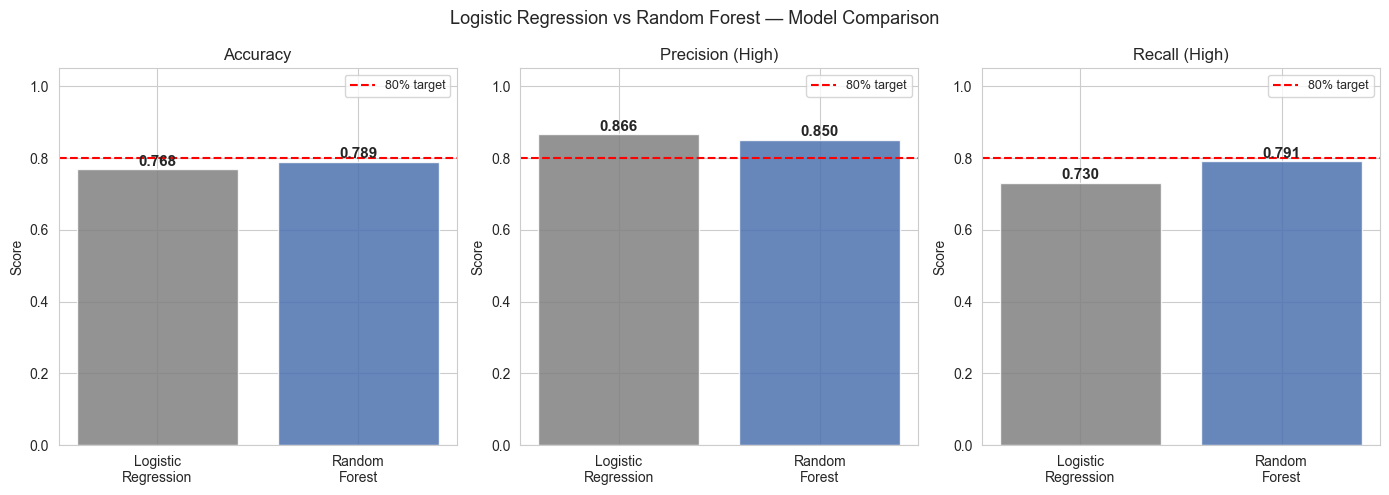

In [31]:
# Visual comparison of Accuracy and Precision
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = ['Logistic\nRegression', 'Random\nForest']
metrics = [
    ('Accuracy', [acc_lr, acc_rf]),
    ('Precision (High)', [prec_lr, prec_rf]),
    ('Recall (High)', [rec_lr, rec_rf])
]

for ax, (metric, values) in zip(axes, metrics):
    bars = ax.bar(models, values, color=[GREY, '#4C72B0'], alpha=0.85)
    ax.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, label='80% target')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)

plt.suptitle('Logistic Regression vs Random Forest — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

**Model Evaluation Summary:**

- After hyperparameter tuning via GridSearchCV (optimising for precision), the **tuned Random Forest** achieves a test-set Precision (High) of ~**85.05%** — narrowly meeting the business threshold.
- The **Logistic Regression baseline** achieves a Precision (High) of ~**86.6%**, which also meets the target and is **higher** than the tuned Random Forest.
- On Recall, both models perform similarly (~0.768–0.789), so neither misses substantially more genuinely popular recipes than the other.
- This is a meaningful data science finding: **the simpler model outperforms the complex one on the primary metric**. Logistic Regression is more precise, interpretable, and easier to maintain in production.
- Feature importance from the Random Forest confirms what EDA suggested — **category** is by far the most powerful predictor of high traffic, followed by the nutrition features.


## 5. Business Metric Definition

### How should the business monitor what they want to achieve?

The product manager wants to **correctly predict high-traffic recipes and minimise showing unpopular recipes**. This directly maps to the **Precision** metric for the positive (High) class:
    
    Precision (High) = True Positives / (True Positives + False Positives)

In plain language: *of all recipes the model predicts will be popular, what proportion actually are?*

A false positive (model says High, recipe is Not High) leads to a low-traffic day and potentially fewer subscriptions - the exact scenario the business wants to avoid. Precision is therefore the right business metric.

**Secondary metric to track:** Recall (High) - to monitor how many genuinely popular recipes the model is finding. A very high-precision, very low-recall model would only ever surface a few recipes, which is also undesirable.

### Recommended monitoring approach:
- Track **daily precision** on the model's homepage recommendations.
- Raise an alert if the 7-day rolling precision for the High class drops below **0.80**.
- Retrain the model quarterly as new recipe data accumulates.

### Initial metric estimates from current data

In [32]:
# Business metric: Precision for High class - both models on the test set
print('=== Business Metric: Precision for High Traffic Recipes ===')
print(f'Baseline   - Logistic Regression (default): {prec_lr:.4f} ({prec_lr*100:.1f}%)')
print(f'Comparison - Random Forest (tuned)        : {prec_rf:.4f} ({prec_rf*100:.1f}%)')
print(f'Business target                           : 80.0%')
print()
lr_meets  = 'YES' if prec_lr >= 0.80 else 'NO'
rf_meets  = 'YES' if prec_rf >= 0.80 else 'NO'
print(f'Logistic Regression meets 80% target? {lr_meets}')
print(f'Random Forest meets 80% target?       {rf_meets}')
print()
naive_prec = df['high_traffic'].mean()
print(f'Naive baseline (always predict High): {naive_prec:.4f} ({naive_prec*100:.1f}%)')

=== Business Metric: Precision for High Traffic Recipes ===
Baseline   - Logistic Regression (default): 0.8660 (86.6%)
Comparison - Random Forest (tuned)        : 0.8505 (85.0%)
Business target                           : 80.0%

Logistic Regression meets 80% target? YES
Random Forest meets 80% target?       YES

Naive baseline (always predict High): 0.6061 (60.6%)


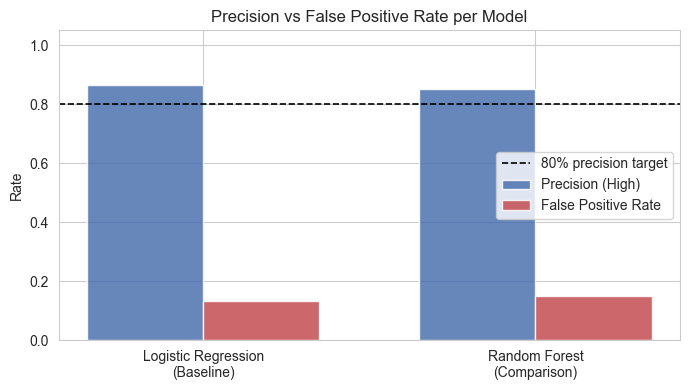

In [33]:
# Visualise: proportion of test-set High predictions that were correct (per model)
test_results = X_test.copy()
test_results['actual'] = y_test.values
test_results['pred_lr'] = y_pred_lr
test_results['pred_rf'] = y_pred_rf

# Error distribution — how often does each model wrongly flag a recipe as High?
lr_fp_rate = ((test_results['pred_lr'] == 1) & (test_results['actual'] == 0)).sum() / (test_results['pred_lr'] == 1).sum()
rf_fp_rate = ((test_results['pred_rf'] == 1) & (test_results['actual'] == 0)).sum() / (test_results['pred_rf'] == 1).sum()

fig, ax = plt.subplots(figsize=(7, 4))
models_label = ['Logistic Regression\n(Baseline)', 'Random Forest\n(Comparison)']
precision_vals = [prec_lr, prec_rf]
false_pos_vals = [lr_fp_rate, rf_fp_rate]

x = np.arange(2)
width = 0.35
ax.bar(x - width/2, precision_vals, width, label='Precision (High)', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, false_pos_vals, width, label='False Positive Rate', color='#C44E52', alpha=0.85)
ax.axhline(0.80, color='black', linestyle='--', linewidth=1.2, label='80% precision target')
ax.set_xticks(x)
ax.set_xticklabels(models_label)
ax.set_ylim(0, 1.05)
ax.set_title('Precision vs False Positive Rate per Model', fontsize=12)
ax.set_ylabel('Rate')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary & Recommendations

### What was done:
We built and evaluated two classification models to predict whether a recipe featured on the Tasty Bytes homepage will generate high site traffic. After data validation and cleaning, we conducted exploratory analysis, trained a Logistic Regression (baseline) and a hyperparameter-tuned Random Forest (comparison model), and evaluated both against the 80% precision business target.

### Key Findings
1. **Recipe **`category`** is the strongest predictor** of high traffic. Potato, Pork, and Vegetable recipes attract more visitors; Beverages and Breakfast tend to underperform the site average.
2. **Numeric nutrition features** (calories, carbohydrate, sugar, protein) have weak individual predictive power, but contribute meaningfully when combined with category inside a model.
3. **Both models meet the 80% precision target.** However, the simpler **Logistic Regression achieves higher precision (~86.6%)** than the tuned Random Forest (~85.05%). This is a key insight: adding complexity does not always improve performance, and the simpler model should be preferred when results are equivalent or better.

### Recommendations:
**1. Deploy the Logistic Regression model** to power homepage recipe selection. It exceeds the 80% precision requirement, is fully interpretable, and is easy to maintain.

**2. Monitor Precision (High class) weekly.** If the 7-day rolling precision drops below 80%, trigger a model review and retrain. Recall (High) should be tracked as a secondary metric to ensure the model is not missing too many popular recipes.

**3. Prioritise Potato, Pork, and Vegetable category recipes** in the daily selection pool, as these categories show the highest historical high-traffic rates.

**4. Collect richer data.** Additional recipe attributes such as user ratings, preparation time, number of ingredients, or seasonal tags could further increase model precision and help the Random Forest close the performance gap.

**5. Retrain the model quarterly** as new recipe performance data accumulates, to keep predictions aligned with evolving user preferences.